<h2>Data Analytics- notebook, empty template</h2>

<h4><b>Dataset name / short description:</b></h4>

Motorcycle Sales Data

<h4><b>Data source (url):</b></h4>

From the Moodle environment.
https://moodle.eoppimispalvelut.fi/pluginfile.php/2838470/mod_resource/content/1/Data_Analytics_Notebook_example.ipynb

<h4><b>Data format:</b></h4>

Describe file structure here.

<h4><b>Data description, features and limitations:</b></h4>

Write needed descriptions here.

<h3><b>Code: importing modules, custom functions and loading the data</b></h3>

In [29]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("motorcycle_sales.csv")
df

,name,selling_price,year,seller_type,owner,km_driven,ex_showroom_price
0,Royal Enfield Classic 350,175000,2019,Individual,1st owner,350,NaN
1,Honda Dio,45000,2017,Individual,1st owner,5650,NaN
2,Royal Enfield Classic Gunmetal Grey,150000,2018,Individual,1st owner,12000,148114.0
3,Yamaha Fazer FI V 2.0 [2016-2018],65000,2015,Individual,1st owner,23000,89643.0
4,Yamaha SZ [2013-2014],20000,2011,Individual,2nd owner,21000,NaN
...,...,...,...,...,...,...,...
1056,Activa 3g,17000,2010,Individual,1st owner,500000,52000.0
1057,Honda CB twister,16000,2012,Individual,1st owner,33000,51000.0
1058,Bajaj Discover 125,15000,2013,Individual,2nd owner,35000,57000.0
1059,Honda CB Shine,12000,2009,Individual,1st owner,53000,58000.0


<h3><b>Code: Data clean-up procedure</b></h3>

There's already a few problems here.

Specifically, the name column has both the brand and model name in it. It's a big jumble of words and a mess. Also, the owner column is a text datatype. We should convert that to an integer type. 

I don't think we can parse both the model and make from the name column. 

In [30]:
# That's quite a few null values, let's drop the column.
df.isna().sum()

# Dropping the column.
df = df.drop('ex_showroom_price', axis=1)


In [31]:
# Let's replace this with numbers, it's more useful that way (for correlations and such)
df['owner'].value_counts()

# We fill the mapper with all the values we're going to translate
category_mapper = {'1st owner':1,
                   '2nd owner':1,
                   '3rd owner':2,
                   '4th owner':3
}

# And we apply the mapper.
df['owner'] = df['owner'].map(category_mapper)
df.head(5)

,name,selling_price,year,seller_type,owner,km_driven
0,Royal Enfield Classic 350,175000,2019,Individual,1,350
1,Honda Dio,45000,2017,Individual,1,5650
2,Royal Enfield Classic Gunmetal Grey,150000,2018,Individual,1,12000
3,Yamaha Fazer FI V 2.0 [2016-2018],65000,2015,Individual,1,23000
4,Yamaha SZ [2013-2014],20000,2011,Individual,1,21000


In [36]:
# Next up, we'll make a custom function that divides the model and make
# This is a bit of a rough solution, but the main idea is to get insights anyways.


def make_divider(row):
    row = row.split(" ")
    row = row[0]
    return row

# And we'll apply the function.
df['model'] = df['name'].apply(make_divider)
df

,name,selling_price,year,seller_type,owner,km_driven,model
0,Royal Enfield Classic 350,175000,2019,Individual,1,350,Royal
1,Honda Dio,45000,2017,Individual,1,5650,Honda
2,Royal Enfield Classic Gunmetal Grey,150000,2018,Individual,1,12000,Royal
3,Yamaha Fazer FI V 2.0 [2016-2018],65000,2015,Individual,1,23000,Yamaha
4,Yamaha SZ [2013-2014],20000,2011,Individual,1,21000,Yamaha
...,...,...,...,...,...,...,...
1056,Activa 3g,17000,2010,Individual,1,500000,Activa
1057,Honda CB twister,16000,2012,Individual,1,33000,Honda
1058,Bajaj Discover 125,15000,2013,Individual,1,35000,Bajaj
1059,Honda CB Shine,12000,2009,Individual,1,53000,Honda


{'Bajaj': 260,
 'Hero': 232,
 'Honda': 204,
 'Royal': 109,
 'Yamaha': 102,
 'TVS': 69,
 'Suzuki': 30,
 'KTM': 24,
 'Mahindra': 6,
 'Vespa': 4,
 'Kawasaki': 4,
 'Jawa': 3,
 'Activa': 3,
 'UM': 3,
 'Aprilia': 2,
 'Harley-Davidson': 2,
 'BMW': 1,
 'Benelli': 1,
 'Yo': 1,
 'Hyosung': 1}

In [45]:
# This custom function will roughly get the make of the motorcycle
def model_parser(row):
    row = row.split(" ")
    row.pop(0)
    row = " ".join(row)
    return row

# And we'll apply the function.
df['make'] = df['name'].apply(model_parser)
df

,name,selling_price,year,seller_type,owner,km_driven,model,make
0,Royal Enfield Classic 350,175000,2019,Individual,1,350,Royal,Enfield Classic 350
1,Honda Dio,45000,2017,Individual,1,5650,Honda,Dio
2,Royal Enfield Classic Gunmetal Grey,150000,2018,Individual,1,12000,Royal,Enfield Classic Gunmetal Grey
3,Yamaha Fazer FI V 2.0 [2016-2018],65000,2015,Individual,1,23000,Yamaha,Fazer FI V 2.0 [2016-2018]
4,Yamaha SZ [2013-2014],20000,2011,Individual,1,21000,Yamaha,SZ [2013-2014]
...,...,...,...,...,...,...,...,...
1056,Activa 3g,17000,2010,Individual,1,500000,Activa,3g
1057,Honda CB twister,16000,2012,Individual,1,33000,Honda,CB twister
1058,Bajaj Discover 125,15000,2013,Individual,1,35000,Bajaj,Discover 125
1059,Honda CB Shine,12000,2009,Individual,1,53000,Honda,CB Shine


---

<h3><b>Code: Data analysis</b></h3>

Use separate markdown cells if you wish to emphasize an important point or additional information for the reader (see vehicle example)

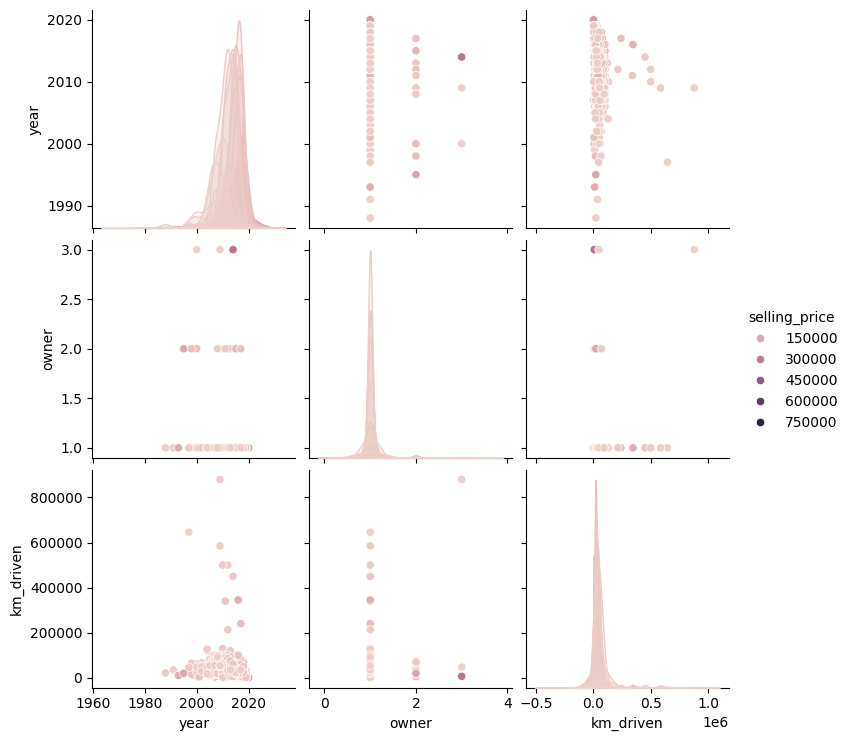

In [47]:
sns.pairplot(df, hue="selling_price")

There's a huge outlier in the data that is skewing this pairplot. Let's look into it a bit more.

In [53]:
# Let's find out the top 10 highest selling prices.
df.sort_values(by=['selling_price'], ascending=False).head(10)

# Yeah, that's quite

,name,selling_price,year,seller_type,owner,km_driven,model,make
295,Suzuki GSX S750,760000,2019,Individual,1,2800,Suzuki,GSX S750
134,Harley-Davidson Street Bob,750000,2013,Individual,1,12000,Harley-Davidson,Street Bob
289,Kawasaki Ninja 650 [2018-2019],425000,2017,Individual,1,13600,Kawasaki,Ninja 650 [2018-2019]
13,Yamaha YZF R3,365000,2019,Individual,1,1127,Yamaha,YZF R3
311,Harley-Davidson Street 750,330000,2014,Individual,3,6500,Harley-Davidson,Street 750
860,Kawasaki Ninja 650 [2018-2019],300000,2011,Individual,1,12000,Kawasaki,Ninja 650 [2018-2019]
344,BMW G310GS,300000,2018,Individual,1,2500,BMW,G310GS
897,Kawasaki Ninja 300,300000,2016,Individual,1,9800,Kawasaki,Ninja 300
130,Royal Enfield Continental GT 650,299000,2019,Individual,1,1500,Royal,Enfield Continental GT 650
315,Royal Enfield Interceptor 650,285000,2019,Individual,1,5500,Royal,Enfield Interceptor 650


<Axes: >

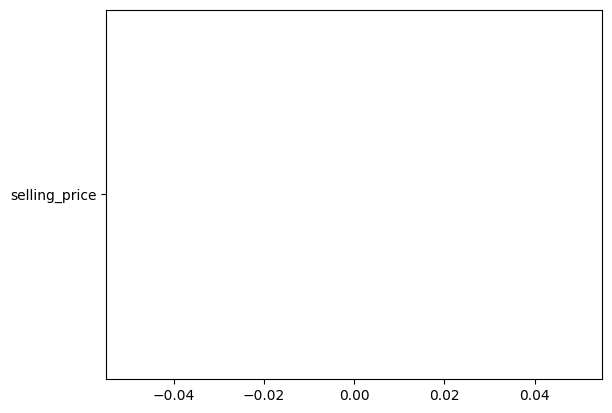

In [55]:
sns.plot('selling_price')

<h3><b>Results and summary:</b></h3>

Write your summary and main results here. 

<h3><b>Ideas for further improvements:</b></h3>

Write your ideas here.